# Validation of the window with integral constraints

In [1]:
import logging

import os

import numpy as np
import matplotlib.pyplot as plt

import lsstypes

logger = logging.getLogger('FIT PNG')

plt.style.use('ec_style.mplstyle')   

# remove warning on my mac -> deactivate on NERSC.
os.environ['OMPI_MCA_btl'] = 'self,tcp'  # deactivate shmem
# disable jax warning:
logging.getLogger("jax._src.xla_bridge").setLevel(logging.ERROR)
logging.getLogger("jax._src.distributed").setLevel(logging.ERROR)
# Remove warning from jax
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

In [2]:
def propose_fiducial(kmin=1e-3, kmax=8e-2, region='GCcomb'):
    propose_fiducial = {}

    propose_fiducial['LRG'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.4, 1.1), 'region': region, 
                               'use_ell2': True, 'kmin': kmin, 'kmax': kmax, 'kmin_ell2': kmin, 'kmax_ell2': kmax}

    propose_fiducial['QSO'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.8, 3.5), 'region': region, 
                               'use_ell2': True, 'kmin': kmin, 'kmax': kmax, 'kmin_ell2': kmin, 'kmax_ell2': kmax}   
      
    return propose_fiducial


def load_data(data_dir, mocks_dir, tracer, fiducial=propose_fiducial(), window_extra='RIC+AMR',
              kpivot=[1e-2, 2e-2], nrebin=[2,2], weight_type_mocks=None):
    """ 
    """
    import lsstypes 

    from tools import read_data, rebin_data

    short_tracer = tracer.replace('_zcmb', '')
    short_tracer = short_tracer.replace('notqso', '')

    if weight_type_mocks is None: weight_type_mocks = 'default-noimsys-fkp-oqe_reshuffle' if window_extra == '' else 'default-fkp-oqe'
    logger.info(f"Reading data for tracer {tracer} with weight type {weight_type_mocks} and window_extra={window_extra}.")

    kwargs = fiducial[short_tracer]

    pk, window, cov, mock = read_data(data_dir=data_dir, mocks_dir=mocks_dir, tracer=tracer, window_extra=window_extra,
                                        weight_type_mocks=weight_type_mocks, **kwargs)
    pk, window, cov, mock = rebin_data(pk, window, cov, mock, tracer=tracer, kpivot=kpivot, nrebin=nrebin, **kwargs)
    try: 
        logger.info(f'After rebinning and k range selection: {pk.get(0).k.shape[0]} and {pk.get(2).k.shape[0]} data points.')
    except KeyError:
        logger.info(f'After rebinning and k range selection: {pk.get(0).k.shape[0]} data points.')

    zeff = {}
    zeff[0] = window.observable.get(0).attrs['zeff']
    try: 
        zeff[2] = window.observable.get(2).attrs['zeff']
    except KeyError:
        pass

    return pk, window, cov, zeff, mock

In [3]:
root = '/global/cfs/cdirs/desi/science/cai/desi-clustering/'
#root = '/Users/edmond/Work/data/desi-clustering/' 

# Where the data are:
data_dir =  root + 'dr2/summary_statistics/local_png/base/desi-data/loa-v1/v2/fNL/blinded'
# Where the mocks are:
mocks_dir = root + 'dr2/summary_statistics/local_png/base/'

+------------------------------------+--------+---------+-------+
| chi2 / (42 - 4) = 1.91 / 38 = 0.05 | varied | bestfit | error |
+------------------------------------+--------+---------+-------+
|              fnl_loc               |  True  |   0.7   |  5.5  |
|            QSO_ell0.sn0            |  True  | -0.053  | 0.048 |
|            QSO_ell0.b1             |  True  |  3.067  | 0.048 |
|          QSO_ell0.sigmas           |  True  |  5.89   | 0.36  |
|            QSO_ell2.b1             |  True  |   2.9   |       |
|          QSO_ell2.sigmas           |  True  |   5.9   |       |
+------------------------------------+--------+---------+-------+


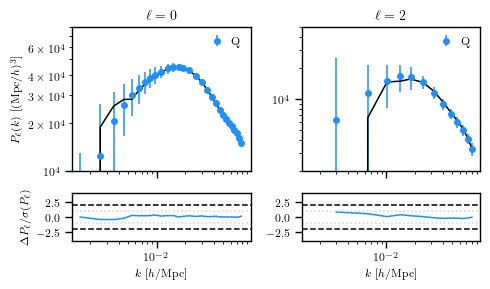

In [4]:
region = 'GCcomb'

pk, window, _, zeff, mocks = load_data(data_dir, mocks_dir, 'QSO', propose_fiducial(region=region), window_extra='RIC+AMR')
zeffs = {'QSOxQSO': zeff}

window_ini = lsstypes.read(data_dir + f'/window_mesh2_spectrum_poles_QSO_z0.8-3.5_{region}_weight-default-fkp-oqe_RIC+AMR.h5')
window_ini = window_ini.at.observable.match(pk)

from tools import get_observable_and_likelihood, run_profiler, plot_observables

obs, lik = get_observable_and_likelihood(lsstypes.mean(mocks), window_ini, mocks, 'QSO', zeffs, engine='camb', fix_fnl=False, nickname='QSO') 
prof = run_profiler(lik)
print(prof.profiles.to_stats(tablefmt="pretty"))
plot_observables({'QSO': obs}, figsize=(5,3), show=True, fn_output='fig/validation_window_0.png')

For now the theory is looking very weird ... Let's check what is going on!


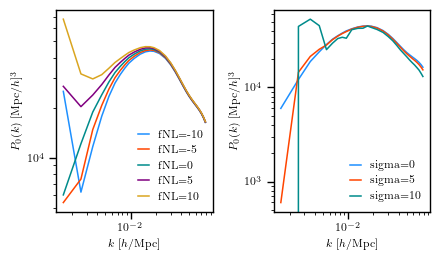

Ok ... something happens when sigma increases... Looks like a small effect propagated into large scales --> This could be a window problem!


In [5]:
print("For now the theory is looking very weird ... Let's check what is going on!")

plt.figure(figsize=(4.5, 2.7))

test = obs[0].copy()

plt.subplot(121)
for fnl in [-10, -5, 0, 5, 10]:
    test(fnl_loc=fnl, **{'QSO_ell0.b1': 3.083, 'QSO_ell0.sn0': -0.065, 'QSO_ell0.sigmas': 0})
    plt.loglog(test.data.get(0).k, test.flattheory, label=f'fNL={fnl}')
plt.legend()
plt.xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
plt.ylabel(r'$P_0(k)$ [Mpc/$h$]$^3$')

plt.subplot(122)
for sigma in [0, 5, 10]:
    test(fnl_loc=0, **{'QSO_ell0.b1': 3.083, 'QSO_ell0.sn0': -0.065, 'QSO_ell0.sigmas': sigma})
    plt.loglog(test.data.get(0).k, test.flattheory, label=f'sigma={sigma}')
plt.legend()
plt.xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
plt.ylabel(r'$P_0(k)$ [Mpc/$h$]$^3$')
plt.tight_layout()
plt.savefig('fig/validation_window_1.png', dpi=400)
plt.show()

print('Ok ... something happens when sigma increases... Looks like a small effect propagated into large scales --> This could be a window problem!')

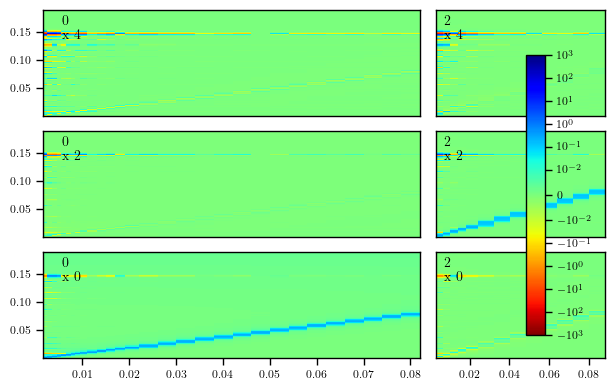

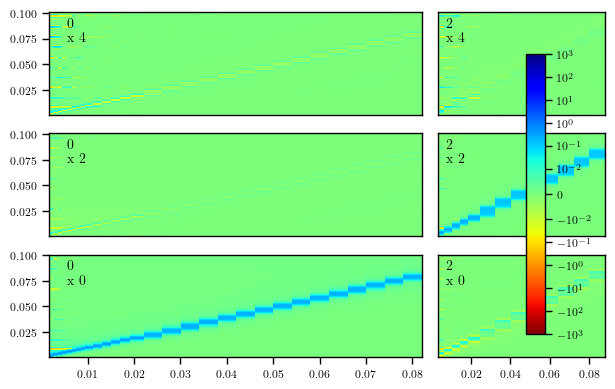

In [6]:
import matplotlib.colors as mcolors
norm_sym = mcolors.SymLogNorm(linthresh=1e-2, linscale=1.0, vmin=-1e3, vmax=1e3)

import warnings
warnings.filterwarnings('ignore', message='.*tight_layout.*')

_ = window_ini.plot(norm=norm_sym, figsize=(5, 4))
plt.savefig('fig/validation_window_2.png', dpi=400)
plt.show()

window_test = window_ini.at.theory.select(k=(1e-4,0.1))

_ = window_test.plot(norm=norm_sym, figsize=(5, 4))
plt.savefig('fig/validation_window_3.png', dpi=400)
plt.show()

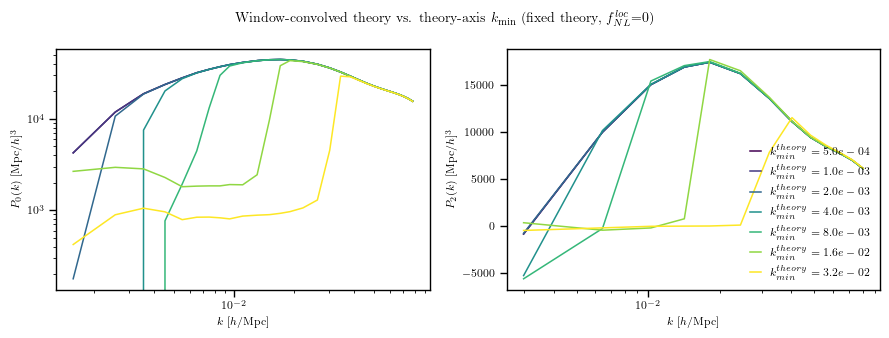

In [13]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Fixed theory parameters (QSO), matching the cells above. Bump fnl_loc to amplify the
# large-scale PNG signal (~1/k^2) where the convolution kmin matters most.
fnl_fixed = 0.0
params0 = {'QSO_ell0.b1': 3.083, 'QSO_ell0.sn0': -0.065, 'QSO_ell0.sigmas': 0.0}
params2 = {'QSO_ell2.b1': 3.083, 'QSO_ell2.sigmas': 0.0}   # sn0 is fixed to 0 for ell=2

# Lower edge of the theory-axis selection to sweep (kmax fixed at 0.1). 5e-4 ~= native grid min.
kmins = np.array([5e-4, 1e-3, 2e-3, 4e-3, 8e-3, 1.6e-2, 3.2e-2])

norm = mcolors.LogNorm(vmin=kmins.min(), vmax=kmins.max())
cmap = cm.viridis

fig, axs = plt.subplots(1, 2, figsize=(9, 3.4))
for kmin_w in kmins:
    color = cmap(norm(kmin_w))
    window_k = window_ini.at.theory.select(k=(kmin_w, 0.1))
    obs_k, _ = get_observable_and_likelihood(lsstypes.mean(mocks), window_k, mocks, 'QSO', zeffs,
                                             engine='camb', fix_fnl=False, nickname='QSO')
    for o in obs_k:
        t = o.copy()
        if 'ell2' in o.name:
            t(fnl_loc=fnl_fixed, **params2)
            axs[1].plot(t.data.get().k, t.flattheory, color=color, label=fr'$k^{{theory}}_{{min}}={kmin_w:.1e}$')
        else:
            t(fnl_loc=fnl_fixed, **params0)
            axs[0].loglog(t.data.get().k, t.flattheory, color=color)

axs[0].set_ylabel(r'$P_0(k)$ [Mpc/$h$]$^3$')
axs[1].set_ylabel(r'$P_2(k)$ [Mpc/$h$]$^3$')
for ax in axs:
    ax.set_xscale('log')
    ax.set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
axs[1].legend(loc='lower right')
fig.suptitle(f'Window-convolved theory vs. theory-axis $k_{{\\min}}$ (fixed theory, $f_{{NL}}^{{loc}}$={fnl_fixed:g})')
plt.show()

*From conversation with Domitille and Arnaud.*

There are "two issues" on this plot:
* The large artifact/spike: it appears right around that k_Nyquist value; in the FM windows before rebinning, the last bin contains modes above k_Nyquist — hence the failure. The key is that the theoretical k_max (input theory) exceeds the Nyquist wavenumber of the observation, which is problematic.
    * Plan: add something in desi-clustering to enforce a theory k_max matched to the Nyquist of the mesh used for the window — this should fully fix the large spike issue.
* The small artifacts: these are rebinning artifacts, expected to not add physically meaningful features in the power spectrum.
    * Plan: change the rebinning kernel to be more visually uniform on the matrix --> but no significant change to the spectrum is expected.

+------------------------------------+--------+---------+-------+
| chi2 / (42 - 4) = 0.98 / 38 = 0.03 | varied | bestfit | error |
+------------------------------------+--------+---------+-------+
|              fnl_loc               |  True  |  -0.2   |  4.3  |
|            QSO_ell0.sn0            |  True  |  0.016  | 0.053 |
|            QSO_ell0.b1             |  True  |  3.069  | 0.046 |
|          QSO_ell0.sigmas           |  True  |  6.07   | 0.40  |
|            QSO_ell2.b1             |  True  |   2.9   |       |
|          QSO_ell2.sigmas           |  True  |   6.1   |       |
+------------------------------------+--------+---------+-------+


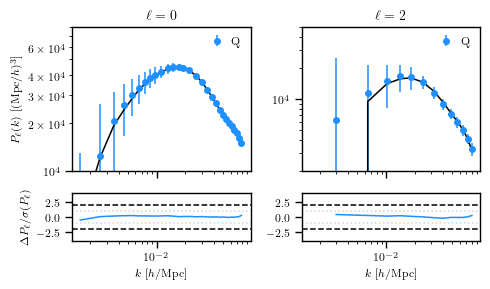

In [43]:
from tools import get_observable_and_likelihood, run_profiler, plot_observables

obs, lik = get_observable_and_likelihood(lsstypes.mean(mocks), window_test, mocks, 'QSO', zeffs, engine='camb', fix_fnl=False, nickname='QSO') 
prof = run_profiler(lik)
print(prof.profiles.to_stats(tablefmt="pretty"))
plot_observables({'QSO': obs}, figsize=(5,3), show=True, fn_output='fig/validation_window_4.png')

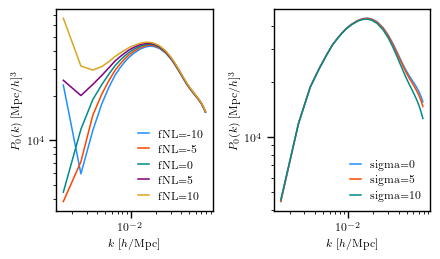

In [45]:
plt.figure(figsize=(4.5, 2.7))
test = obs[0].copy()
plt.subplot(121)
for fnl in [-10, -5, 0, 5, 10]:
    test(fnl_loc=fnl, **{'QSO_ell0.b1': 3.083, 'QSO_ell0.sn0': -0.065, 'QSO_ell0.sigmas': 0})
    plt.loglog(test.data.get(0).k, test.flattheory, label=f'fNL={fnl}')
plt.legend()
plt.xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
plt.ylabel(r'$P_0(k)$ [Mpc/$h$]$^3$')

plt.subplot(122)
for sigma in [0, 5, 10]:
    test(fnl_loc=0, **{'QSO_ell0.b1': 3.083, 'QSO_ell0.sn0': -0.065, 'QSO_ell0.sigmas': sigma})
    plt.loglog(test.data.get(0).k, test.flattheory, label=f'sigma={sigma}')
plt.legend()
plt.xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
plt.ylabel(r'$P_0(k)$ [Mpc/$h$]$^3$')
plt.tight_layout()
plt.show()

# Let's check the LRGs as well, to see if the problem is similar or not:

+------------------------------------+--------+---------+-------+
| chi2 / (42 - 4) = 4.84 / 38 = 0.13 | varied | bestfit | error |
+------------------------------------+--------+---------+-------+
|              fnl_loc               |  True  |  -3.0   |  4.1  |
|            LRG_ell0.sn0            |  True  |  0.027  | 0.049 |
|            LRG_ell0.b1             |  True  |  2.157  | 0.025 |
|          LRG_ell0.sigmas           |  True  |  3.98   | 0.35  |
|            LRG_ell2.b1             |  True  |   2.2   |       |
|          LRG_ell2.sigmas           |  True  |   4.0   |       |
+------------------------------------+--------+---------+-------+


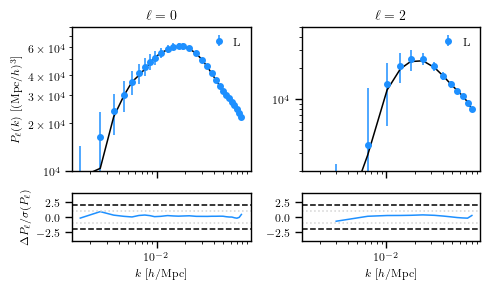

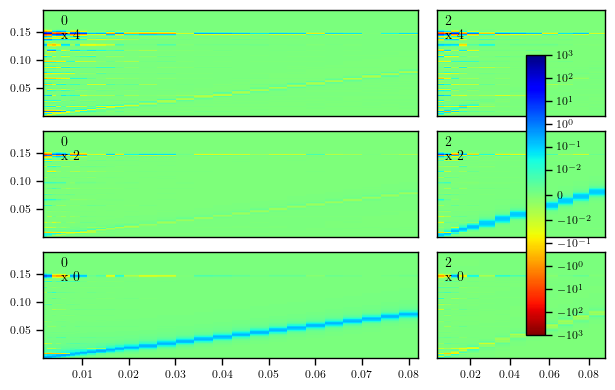

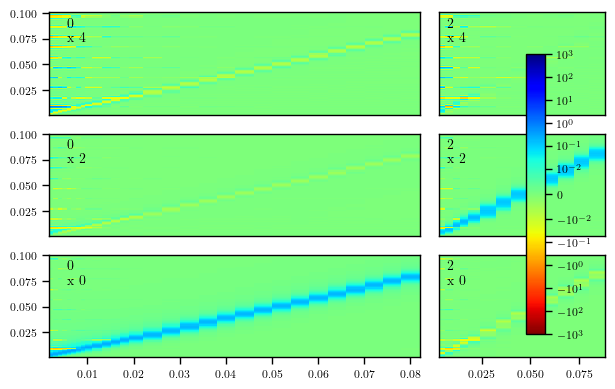

+------------------------------------+--------+---------+-------+
| chi2 / (42 - 4) = 5.80 / 38 = 0.15 | varied | bestfit | error |
+------------------------------------+--------+---------+-------+
|              fnl_loc               |  True  |  -3.3   |  3.5  |
|            LRG_ell0.sn0            |  True  |  0.068  | 0.053 |
|            LRG_ell0.b1             |  True  |  2.151  | 0.026 |
|          LRG_ell0.sigmas           |  True  |  3.92   | 0.38  |
|            LRG_ell2.b1             |  True  |   2.1   |       |
|          LRG_ell2.sigmas           |  True  |   3.9   |       |
+------------------------------------+--------+---------+-------+


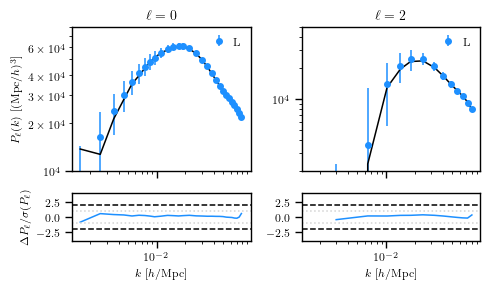

In [13]:
pk, window, _, zeff, mocks = load_data(data_dir, mocks_dir, 'LRG', propose_fiducial(), window_extra='RIC+AMR')
zeffs = {'LRGxLRG': zeff}

window_ini = lsstypes.read(data_dir + '/window_mesh2_spectrum_poles_LRG_z0.4-1.1_GCcomb_weight-default-fkp-oqe_RIC+AMR.h5')
window_ini = window_ini.at.observable.match(pk)

from tools import get_observable_and_likelihood, run_profiler, plot_observables

obs, lik = get_observable_and_likelihood(lsstypes.mean(mocks), window_ini, mocks, 'LRG', zeffs, engine='camb', fix_fnl=False, nickname='LRG') 
prof = run_profiler(lik)
print(prof.profiles.to_stats(tablefmt="pretty"))
plot_observables({'LRG': obs}, figsize=(5,3), show=True)

import matplotlib.colors as mcolors
norm_sym = mcolors.SymLogNorm(linthresh=1e-2, linscale=1.0, vmin=-1e3, vmax=1e3)
import warnings
warnings.filterwarnings('ignore', message='.*tight_layout.*')
_ = window_ini.plot(norm=norm_sym, figsize=(5, 4))
plt.show()

window_test = window_ini.at.theory.select(k=(1e-4,0.1))
_ = window_test.plot(norm=norm_sym, figsize=(5, 4))
plt.show()


obs, lik = get_observable_and_likelihood(lsstypes.mean(mocks), window_test, mocks, 'LRG', zeffs, engine='camb', fix_fnl=False, nickname='LRG') 
prof = run_profiler(lik)
print(prof.profiles.to_stats(tablefmt="pretty"))
plot_observables({'LRG': obs}, figsize=(5,3), show=True)

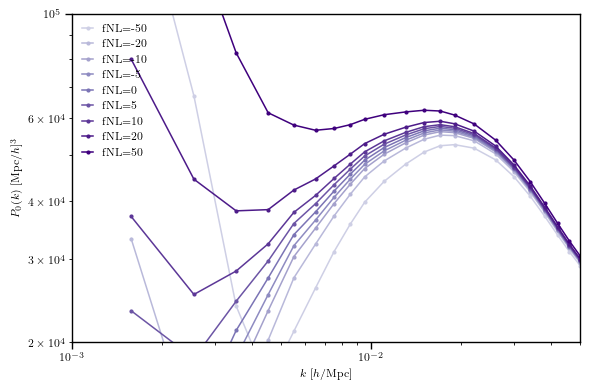

In [30]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

plt.figure(figsize=(6, 4))

fnl_values = [-50, -20, -10, -5, 0, 5, 10, 20, 50]
colors = cm.Purples(np.linspace(0.3, 1.0, len(fnl_values)))  # avoid near-white at the low end

test = obs[0].copy()
for fnl, color in zip(fnl_values, colors):
    test(fnl_loc=fnl, **{'LRG_ell0.b1': 2.1, 'LRG_ell0.sn0': -0.065, 'LRG_ell0.sigmas': 0})
    plt.loglog(test.data.get(0).k, test.flattheory, label=f'fNL={fnl}',
               marker='o', markersize=2, color=color)

plt.ylim([2e4, 1e5])
plt.xlim([1e-3, 5e-2])
plt.legend()
plt.xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
plt.ylabel(r'$P_0(k)$ [Mpc/$h$]$^3$')
plt.tight_layout()
plt.show()

#